## Fit data from 2021-04-08

This data showed a "double Gaussian" feature that wasn't reproducible...

In [1]:
%matplotlib notebook

import numpy as np
import pandas as pd

from scipy.optimize import leastsq
from matplotlib import pyplot as plt

from thermo import *

In [3]:
raw  = load_raw('./data/2021-04-08_174018_wtMpro_melt_run2.txt', cycles=620)
melt = load_melt('./data/2021-04-08_174018_wtMpro_melt_run2.txt')

df = pd.DataFrame(melt)
df

,temperature,A10,A11,A12,B10,B11,B12,C10,C11,C12,...,D12,E10,E11,E12,F10,F11,F12,G10,G11,G12
0,24.880,1074.903,176.685,1230.948,-475.007,-22.782,-309.819,96.673,555.451,293.001,...,120.003,156.826,422.645,-152.238,69.692,630.639,-24.466,879.355,1211.432,157.165
1,24.995,999.097,375.052,1361.169,-436.341,48.190,-262.915,81.767,564.643,319.816,...,185.154,127.012,447.459,-134.352,74.560,686.941,-19.235,798.857,1260.965,203.532
2,25.110,956.937,649.464,1373.901,-365.312,158.898,-177.090,58.655,551.249,348.777,...,231.142,106.462,469.085,-118.459,92.018,784.902,-7.840,720.965,1269.638,271.305
3,25.224,934.566,923.685,1262.213,-259.840,298.419,-37.580,43.823,518.966,378.045,...,248.282,98.542,472.640,-103.532,132.666,879.488,14.534,648.936,1203.874,362.866
4,25.339,913.519,1117.442,1067.686,-130.825,438.897,152.031,55.696,482.105,406.266,...,238.307,103.054,449.758,-88.604,202.166,914.062,56.496,585.481,1055.992,460.213
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606,94.392,-124.191,106.863,-106.796,81.855,86.237,-281.292,-961.862,-1884.002,-5327.753,...,-2645.213,-134.413,-497.922,-29.150,89.098,-142.965,254.749,-2874.191,-756.841,-555.403
607,94.506,-191.283,29.762,-4.752,80.885,-335.518,-533.374,-1008.020,-2125.484,-5597.790,...,-3085.483,-150.558,-634.569,-137.150,73.677,-119.793,159.490,-2804.625,-934.650,-776.550
608,94.621,-259.795,-186.030,37.707,65.943,-790.259,-831.087,-1044.445,-2403.491,-5911.889,...,-3625.455,-177.087,-763.304,-255.599,53.475,-86.497,27.040,-2760.354,-1086.503,-1067.862
609,94.736,-323.657,-456.889,21.044,56.665,-1023.568,-1047.626,-1065.650,-2667.813,-6231.491,...,-4177.034,-205.715,-873.602,-374.074,48.981,-53.552,-82.708,-2745.020,-1221.005,-1372.940


In [4]:
def double_gaussian( x, params ):
    (c1, mu1, sigma1, c2, mu2, sigma2) = params
    res =   c1 * np.exp( - (x - mu1)**2.0 / (2.0 * sigma1**2.0) ) \
          + c2 * np.exp( - (x - mu2)**2.0 / (2.0 * sigma2**2.0) )
    return res

<IPython.core.display.Javascript object>


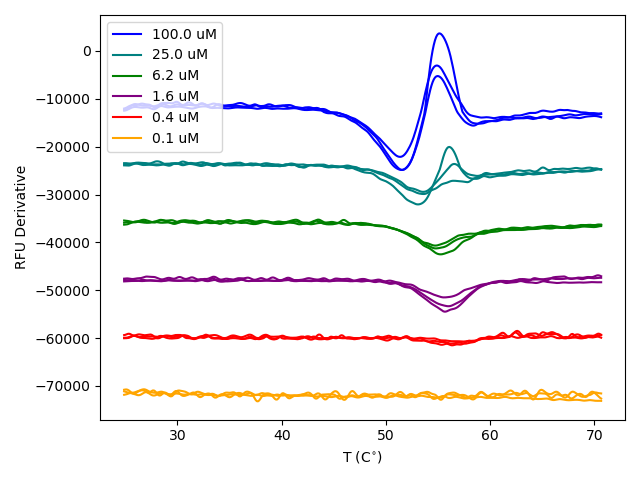

In [5]:
high_T_cutoff = 400

T = df.to_numpy()[:high_T_cutoff,0]
x = df.to_numpy()[:high_T_cutoff,1:]

colors = ['k', 'b', 'teal', 'green', 'purple', 'r', 'orange']
plt.figure()
ax = plt.subplot(111)

for i in range(1, x.shape[1]//3):
    
    for j in range(3):
        if j == 0:
            mylabel = '%.1f uM' % (400.0/(4**i),)
        else:
            mylabel = '_no_legend_'
        ax.plot(T, x[:,i*3 + j] - i * 12000, color=colors[i], label=mylabel)
    
plt.xlabel('T (C$^{\circ}$)')
plt.ylabel('RFU Derivative')
plt.legend(loc=2)

plt.tight_layout()
plt.show()

(array([-8.81793411e+03,  5.46367690e+01,  3.48851456e+00,  1.15266270e+04,
        5.60540955e+01,  1.13378281e+00]), 1)


<IPython.core.display.Javascript object>


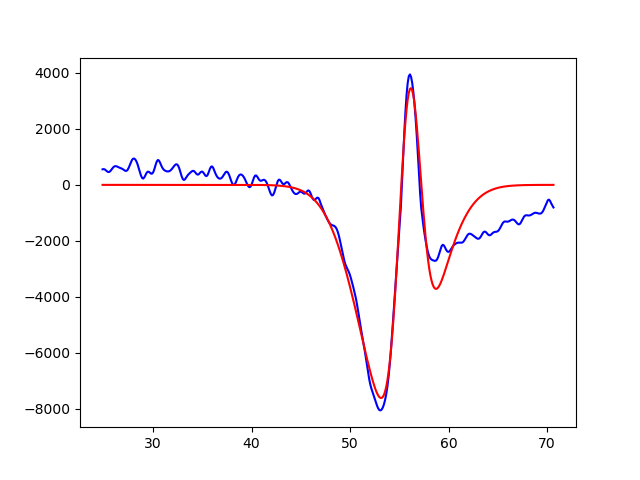

In [6]:
# let's try to fit one to a double-gaussian

def fit_double_gaussian(x, y):
    
    x0 = [-1000.0,52.0,1.0, 1000.0,57.0,1.0] # c1, mu1, sigma1, c2, mu2, sigma2
    
    def dgf(params):
        fit = double_gaussian(x, params)
        return (fit - y)
    
    fit = leastsq(dgf, x0)

    return fit

y = x[:,7]
fit = fit_double_gaussian(T, y)
print(fit)

plt.figure()
plt.plot( T, y, c='b' )
plt.plot( T, double_gaussian(T, fit[0]), c='r' )
plt.show()

In [7]:
# loop over all the datasets and plot!

conc = 400.0 # protein concentration, 4x serial dilution every 3 wells

concs = []
A1s = []
A2s = []
mu1s = []
mu2s = []

for i in range(3, x.shape[1]):
    
    if i % 3 == 0:
        conc /= 4.0
        
    a1, m1, _, a2, m2, _ = fit_double_gaussian(T, x[:,i])[0]
    
    concs.append(conc)
    
    A1s.append(a1 / conc)
    A2s.append(a2 / conc)
    
    mu1s.append(m1)
    mu2s.append(m2)

/Users/TJ/opt/miniconda3/lib/python3.8/site-packages/scipy/optimize/minpack.py:475: RuntimeWarning: Number of calls to function has reached maxfev = 1400.
  warnings.warn(errors[info][0], RuntimeWarning)


<IPython.core.display.Javascript object>


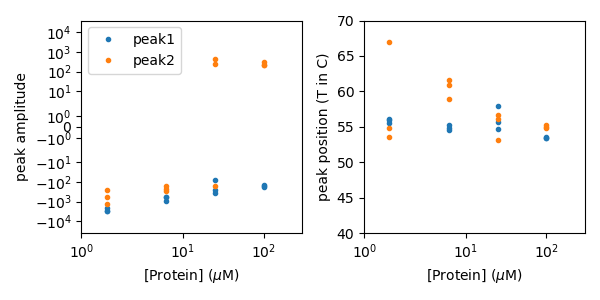

In [8]:
plt.figure(figsize=(6,3))

plt.subplot(121)
plt.plot(concs, A1s, '.')
plt.plot(concs, A2s, '.')

plt.xscale('symlog')
plt.yscale('symlog')

plt.ylim([-40000, 40000])
plt.xlim([1, 300])

plt.xlabel('[Protein] ($\mu$M)')
plt.ylabel('peak amplitude')
plt.legend(['peak1', 'peak2'])

plt.subplot(122)
plt.plot(concs, mu1s, '.')
plt.plot(concs, mu2s, '.')

plt.xscale('symlog')

plt.ylim([40, 70])
plt.xlim([1, 300])

plt.xlabel('[Protein] ($\mu$M)')
plt.ylabel('peak position (T in C)')

plt.tight_layout()
plt.show()